<a href="https://colab.research.google.com/github/l22140169-arch/Analisis-y-visualizacion-de-datos/blob/main/Evaluacion_Unidad2_Virgen_Soto_Adriana_Scarlett_An%C3%A1lisis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVALUACIÓN TEÓRICA: REGRESIÓN

## Responde correctamente las siguientes preguntas:

A) En el modelo general de regresión Y = f(X) + ε, ¿qué representa el término ε?
1. La pendiente de la recta de regresión
2. El error irreducible, de media cero, independiente de X
3. La proporción de varianza explicada por el modelo
4. El coeficiente de determinación R²

B) El método de Mínimos Cuadrados Ordinarios (OLS) estima los parámetros β₀ y β₁ minimizando:
1. La suma de los valores absolutos de los residuos (MAE)
2. El coeficiente de determinación R²
3. La Suma de Cuadrados de los Residuos: RSS = Σ(yᵢ − β̂₀ − β̂₁xᵢ)²
4. El Criterio de Información de Akaike (AIC)

C) En el output de un modelo en R, un predictor tiene p-value (Pr(>|t|)) = 0.860. ¿Qué significa esto?
1. El predictor es altamente significativo y debe mantenerse en el modelo
2. El predictor explica el 86% de la varianza de Y
3. NO hay evidencia estadística de que el predictor impacte en Y (no es significativo)
4. El modelo tiene un error del 86%

D) En la regresión lineal múltiple, el coeficiente βⱼ se interpreta como:
1. La correlación total entre Xⱼ e Y
2. El cambio promedio en Y por unidad de aumento en Xⱼ, manteniendo constantes todos los demás predictores (ceteris paribus)
3. El porcentaje de varianza explicada por Xⱼ
4. La probabilidad de que Xⱼ sea significativo

E) En el dataset Advertising, la variable "newspaper" parece significativa en el modelo simple pero NO lo es en el modelo múltiple. Este fenómeno se conoce como:
1. Homocedasticidad
2. Overfitting (sobreajuste)
3. Confusión (confounding) — newspaper está correlacionada con radio
4. Multicolinealidad perfecta

F) ¿Cuál de los siguientes NO es un supuesto de la regresión lineal?
1. Linealidad entre X e Y
2. Homocedasticidad (varianza constante de errores)
3. Los predictores deben ser variables categóricas
4. Normalidad de los residuos

G) ¿Cuál es la diferencia principal entre R² y R² Ajustado?
1. R² Ajustado siempre es mayor que R²
2. R² Ajustado penaliza por el número de predictores, evitando que agregar variables inútiles infle el valor
3. R² solo funciona para regresión simple y R² Ajustado para múltiple
4. No hay diferencia; son equivalentes

H) En la validación cruzada K-Fold con K=10, ¿qué ocurre en cada iteración?
1. Se usan 10% de los datos para entrenar y 90% para probar
2. Se divide el dataset en 10 partes; se entrena con 9 partes y se evalúa con la parte restante, rotando 10 veces
3. Se ejecuta el modelo 10 veces con los mismos datos
4. Se eliminan el 10% de los outliers en cada iteración



In [1]:
#Agrega tus respuestas aquí
a=2
b=3
c=3
d=2
e=3
f=3
g=2
h=2
print("Respuestas")
Lista=list(paste("A=",a),paste("B=",b),paste("C=",c),paste("D=",d),paste("E=",e),paste("F=",f),paste("G=",g),paste("H=",h))
Lista

[1] "Respuestas"


[[1]]
[1] "A= 2"

[[2]]
[1] "B= 3"

[[3]]
[1] "C= 3"

[[4]]
[1] "D= 2"

[[5]]
[1] "E= 3"

[[6]]
[1] "F= 3"

[[7]]
[1] "G= 2"

[[8]]
[1] "H= 2"

# EVALUACIÓN PRÁCTICA: REGRESIÓN COMO HERRAMIENTA DE ANÁLISIS PREDICTIVO
## Dataset: NBA Draft 2015 (FiveThirtyEight)

**Asignatura:** Análisis de Datos  
**Duración:** 30 minutos  
**Herramienta:** R en Google Colab  
**Valor total:** 100 puntos  

---

### Instrucciones generales
1. Escribe tu código en las celdas indicadas con `# TU CÓDIGO AQUÍ`
2. Ejecuta cada celda para verificar que funciona antes de avanzar
3. Responde las preguntas de interpretación en las celdas de texto correspondientes
4. Al terminar, descarga tu notebook (File → Download → Download .ipynb)

---

### Contexto del negocio
Eres analista de datos en un equipo de la NBA. La gerencia deportiva necesita un modelo predictivo que estime el **rendimiento proyectado** (`projected_spm` = Statistical Plus-Minus proyectado) de los prospectos del draft, utilizando variables como su probabilidad de ser **superstar**, **starter**, **role player** o **bust**, su **posición** y su **año de draft**. Tu trabajo es construir, evaluar y comparar modelos de regresión para apoyar la toma de decisiones en el próximo draft.


---
## Paso 0: Preparación del entorno (ya resuelto)
Ejecuta las siguientes celdas para instalar las librerías y cargar los datos. **No modifiques estas celdas.**

In [2]:
# Instalar paquetes necesarios (ejecutar una sola vez)
install.packages("fivethirtyeight", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("ggplot2", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("caret", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("Metrics", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("lmtest", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("car", repos="https://cran.r-project.org", quiet=TRUE)
install.packages("MASS", repos="https://cran.r-project.org", quiet=TRUE)


also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’


also installing the dependency ‘zoo’


also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘urca’, ‘RcppArmadillo’, ‘cowplot’, ‘Deriv’, ‘forecast’, ‘microbenchmark’, ‘rbibutils’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’




In [3]:
# Cargar todas las librerías
library(fivethirtyeight)
library(ggplot2)
library(caret)
library(Metrics)
library(lmtest)
library(car)
library(MASS)

# Cargar el dataset NBA Draft 2015
data(nba_draft_2015)

# Exploración inicial
cat("Dimensiones:", dim(nba_draft_2015), "\n")
cat("Columnas:", names(nba_draft_2015), "\n\n")
str(nba_draft_2015)
head(nba_draft_2015, 10)

Some larger datasets need to be installed separately, like senators and
house_district_forecast. To install these, we recommend you install the
fivethirtyeightdata package by running:
install.packages('fivethirtyeightdata', repos =
'https://fivethirtyeightdata.github.io/drat/', type = 'source')

Loading required package: lattice


Attaching package: ‘Metrics’


The following objects are masked from ‘package:caret’:

    precision, recall


Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: carData



Dimensiones: 1090 9 
Columnas: player position id draft_year projected_spm superstar starter role_player bust 

tibble [1,090 × 9] (S3: tbl_df/tbl/data.frame)
 $ player       : chr [1:1090] "Karl-Anthony Towns" "Justise Winslow" "Stanley Johnson" "Jahlil Okafor" ...
 $ position     : chr [1:1090] "C" "SF" "SF" "C" ...
 $ id           : chr [1:1090] "karl-anthony-towns" "justise-winslow" "stanley-johnson" "jahlil-okafor" ...
 $ draft_year   : int [1:1090] 2015 2015 2015 2015 2015 2015 2015 2015 2015 2015 ...
 $ projected_spm: num [1:1090] 1.031 0.875 0.679 0.522 0.512 ...
 $ superstar    : num [1:1090] 0.1348 0.0835 0.0678 0.0587 0.152 ...
 $ starter      : num [1:1090] 0.427 0.511 0.424 0.41 0.342 ...
 $ role_player  : num [1:1090] 0.1631 0.1768 0.2785 0.2355 0.0966 ...
 $ bust         : num [1:1090] 0.275 0.229 0.23 0.296 0.409 ...
 - attr(*, "spec")=List of 2
  ..$ cols   :List of 9
  .. ..$ Player       : list()
  .. .. ..- attr(*, "class")= chr [1:2] "collector_character" "collecto

player,position,id,draft_year,projected_spm,superstar,starter,role_player,bust
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Karl-Anthony Towns,C,karl-anthony-towns,2015,1.0306057,0.13476667,0.4271833,0.16308333,0.2749667
Justise Winslow,SF,justise-winslow,2015,0.8753290,0.08352857,0.5109048,0.17676667,0.2288000
Stanley Johnson,SF,stanley-johnson,2015,0.6794933,0.06780000,0.4237333,0.27850000,0.2299667
Jahlil Okafor,C,jahlil-okafor,2015,0.5216613,0.05871667,0.4099000,0.23553333,0.2958500
D`Angelo Russell,PG,d-angelo-russell,2015,0.5119667,0.15203333,0.3422833,0.09658333,0.4091000
Dakari Johnson,C,dakari-johnson,2015,0.4917874,0.02134078,0.3675436,0.41757200,0.1935437
Devin Booker,SG,3-devin-booker,2015,0.4725773,0.07336667,0.3244667,0.39016667,0.2120000
Willie Cauley-Stein,C,willie-cauley-stein,2015,0.3511714,0.04711445,0.4059899,0.24318572,0.3037100
Rondae Hollis-Jefferson,SF,rondae-hollis-jefferson,2015,0.3119092,0.01458978,0.3685331,0.39248067,0.2243964


### Descripción de las variables

| Variable | Descripción |
|---|---|
| `player` | Nombre del jugador |
| `position` | Posición: PG, SG, SF, PF, C |
| `id` | Identificador numérico |
| `draft_year` | Año del draft (2001-2015) |
| `projected_spm` | **Variable dependiente (Y):** Statistical Plus-Minus proyectado (temporadas 2-5). Mide el impacto del jugador: 0 = promedio, +5 = All-NBA, -2 = reemplazo, -5 = muy malo |
| `superstar` | Probabilidad de ser superstar (0 a 1) |
| `starter` | Probabilidad de ser titular (0 a 1) |
| `role_player` | Probabilidad de ser jugador de rol (0 a 1) |
| `bust` | Probabilidad de ser bust/fracaso (0 a 1) |

In [4]:
# Ver resumen estadístico de las variables numéricas clave
summary(nba_draft_2015[, c("projected_spm", "superstar", "starter", "role_player", "bust", "draft_year")])

 projected_spm       superstar            starter         role_player     
 Min.   :-1.6847   Min.   :0.0000000   Min.   :0.00426   Min.   :0.07613  
 1st Qu.:-1.2109   1st Qu.:0.0001052   1st Qu.:0.03510   1st Qu.:0.32285  
 Median :-1.0281   Median :0.0008274   Median :0.06702   Median :0.36810  
 Mean   :-0.8101   Mean   :0.0114125   Mean   :0.12401   Mean   :0.35572  
 3rd Qu.:-0.5639   3rd Qu.:0.0056225   3rd Qu.:0.18696   3rd Qu.:0.40371  
 Max.   : 1.7768   Max.   :0.1819789   Max.   :0.65572   Max.   :0.54387  
      bust          draft_year  
 Min.   :0.1614   Min.   :2001  
 1st Qu.:0.4299   1st Qu.:2005  
 Median :0.5250   Median :2009  
 Mean   :0.5089   Mean   :2008  
 3rd Qu.:0.5964   3rd Qu.:2012  
 Max.   :0.8263   Max.   :2015  

---
## Pregunta 1: Regresión Lineal Simple (20 puntos)

### 1a) Ajustar el modelo (10 pts)
Ajusta un modelo de regresión lineal simple que prediga `projected_spm` en función de `superstar`.  
Muestra el `summary()` del modelo.


In [6]:
# TU CÓDIGO AQUÍ
# Ajusta: modelo_simple <- lm(...)
# 1a) Ajustar el modelo de regresión lineal simple
# La sintaxis es: lm(Variable_Dependiente ~ Variable_Independiente, data = nombre_dataset)
modelo_simple <- lm(projected_spm ~ superstar, data = nba_draft_2015)

# Muestra: summary(...)
summary(modelo_simple)



Call:
lm(formula = projected_spm ~ superstar, data = nba_draft_2015)

Residuals:
     Min       1Q   Median       3Q      Max 
-1.47673 -0.23267 -0.06833  0.20348  1.66077 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -1.00137    0.01093  -91.59   <2e-16 ***
superstar   16.75747    0.35675   46.97   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.335 on 1088 degrees of freedom
Multiple R-squared:  0.6697,	Adjusted R-squared:  0.6694 
F-statistic:  2206 on 1 and 1088 DF,  p-value: < 2.2e-16


### 1b) Visualización (10 pts)
Crea un gráfico de dispersión de `superstar` vs `projected_spm` con la recta de regresión usando `ggplot2` y `geom_smooth(method='lm')`.


`geom_smooth()` using formula = 'y ~ x'


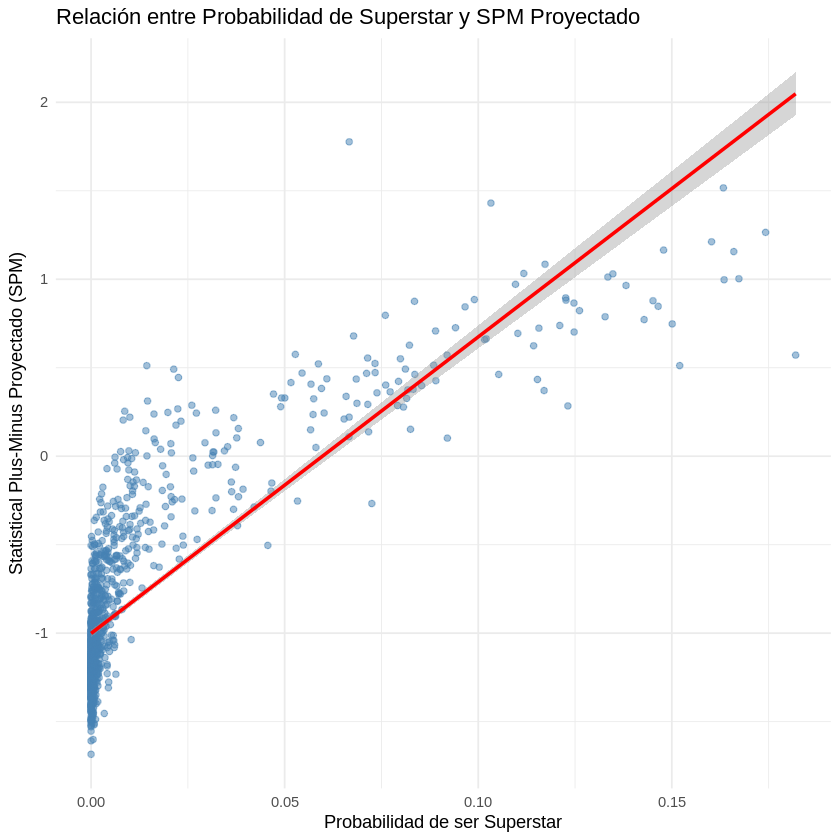

In [7]:
# TU CÓDIGO AQUÍ
# ggplot(nba_draft_2015, aes(x = ..., y = ...)) + ...

ggplot(nba_draft_2015, aes(x = superstar, y = projected_spm)) +
  geom_point(alpha = 0.5, color = "steelblue") +  # Gráfico de puntos con transparencia
  geom_smooth(method = 'lm', color = "red", se = TRUE) + # Recta de regresión en rojo
  labs(title = "Relación entre Probabilidad de Superstar y SPM Proyectado",
       x = "Probabilidad de ser Superstar",
       y = "Statistical Plus-Minus Proyectado (SPM)") +
  theme_minimal()


---
## Pregunta 2: Regresión Lineal Múltiple (20 puntos)

### 2a) Ajustar modelo múltiple (10 pts)
Ajusta un modelo de regresión lineal múltiple que prediga `projected_spm` usando **tres** predictores: `superstar`, `starter` y `bust`.  
Muestra el `summary()`.


In [8]:
# TU CÓDIGO AQUÍ
# Ajusta: modelo_mult <- lm(...)
# Fórmula: Y ~ X1 + X2 + X3

modelo_multiple <- lm(projected_spm ~ superstar + starter + bust, data = nba_draft_2015)

# Muestra: summary(...)
summary(modelo_multiple)



Call:
lm(formula = projected_spm ~ superstar + starter + bust, data = nba_draft_2015)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.25232 -0.02259  0.00217  0.02362  0.50388 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.25479    0.01647  -15.47   <2e-16 ***
superstar    5.71769    0.08096   70.62   <2e-16 ***
starter      2.17925    0.03180   68.53   <2e-16 ***
bust        -1.75069    0.02620  -66.81   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.04859 on 1086 degrees of freedom
Multiple R-squared:  0.9931,	Adjusted R-squared:  0.993 
F-statistic: 5.184e+04 on 3 and 1086 DF,  p-value: < 2.2e-16


### 2b) Variable categórica: posición (10 pts)
Ahora ajusta un modelo que incluya los tres predictores anteriores **más** la variable `position` como factor.  
Muestra el `summary()` y los `contrasts()` de la variable `position`.


In [10]:
# TU CÓDIGO AQUÍ
# Aseguramos que 'position' sea tratada como factor
nba_draft_2015$position <- as.factor(nba_draft_2015$position)

# modelo_cat <- lm(projected_spm ~ superstar + starter + bust + factor(position), ...)
modelo_categorico <- lm(projected_spm ~ superstar + starter + bust + position,
                        data = nba_draft_2015)

# summary(...)
summary(modelo_categorico)

# contrasts(as.factor(nba_draft_2015$position))
contrasts(nba_draft_2015$position)


Call:
lm(formula = projected_spm ~ superstar + starter + bust + position, 
    data = nba_draft_2015)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.24934 -0.02281  0.00284  0.02350  0.50975 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.243742   0.017998 -13.543  < 2e-16 ***
superstar    5.764191   0.081780  70.484  < 2e-16 ***
starter      2.142752   0.033215  64.512  < 2e-16 ***
bust        -1.778188   0.027118 -65.573  < 2e-16 ***
positionPF   0.012980   0.005213   2.490  0.01293 *  
positionPG   0.014874   0.005360   2.775  0.00561 ** 
positionSF   0.008350   0.005389   1.550  0.12154    
positionSG  -0.003225   0.005338  -0.604  0.54591    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.04816 on 1082 degrees of freedom
Multiple R-squared:  0.9932,	Adjusted R-squared:  0.9932 
F-statistic: 2.262e+04 on 7 and 1082 DF,  p-value: < 2.2e-16


,PF,PG,SF,SG
C,0,0,0,0
PF,1,0,0,0
PG,0,1,0,0
SF,0,0,1,0
SG,0,0,0,1


---
## Pregunta 3: Diagnóstico del Modelo (20 puntos)

### 3a) Gráficos de diagnóstico (10 pts)
Usando el modelo múltiple de la Pregunta 2a (con `superstar`, `starter` y `bust`), genera los 4 gráficos de diagnóstico con `plot()` en un layout 2x2.


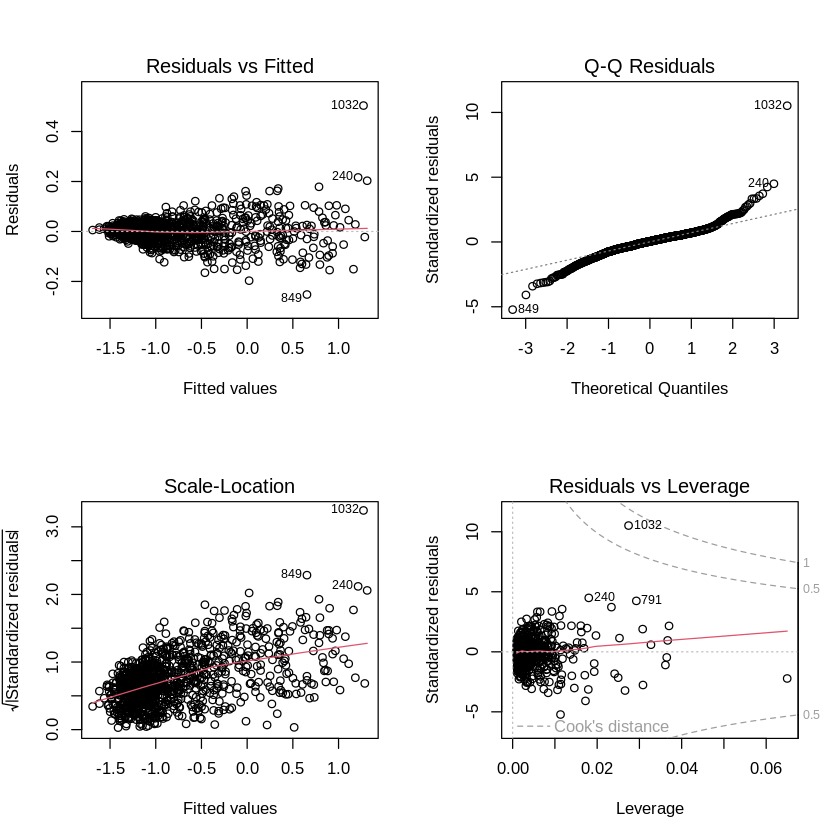

In [13]:
# TU CÓDIGO AQUÍ
# par(mfrow = c(2, 2))
par(mfrow = c(2, 2))

# plot(...)
plot(modelo_multiple)

### 3b) Prueba de homocedasticidad y multicolinealidad (10 pts)
Realiza:
1. La prueba de Breusch-Pagan (`bptest()`) para homocedasticidad
2. El cálculo de VIF (`vif()`) para multicolinealidad


In [14]:
# TU CÓDIGO AQUÍ
# bptest(...)
library(lmtest)
bptest(modelo_multiple)

# vif(...)
library(car)
vif(modelo_multiple)


	studentized Breusch-Pagan test

data:  modelo_multiple
BP = 152.4, df = 3, p-value < 2.2e-16


superstar   starter      bust 
 2.448596  6.889299  4.433693

---
## Pregunta 4: Train/Test Split y Validación Cruzada (20 puntos)

### 4a) División Train/Test 70/30 (10 pts)
Divide el dataset en 70% entrenamiento y 30% prueba (usa `set.seed(123)`).  
Entrena el modelo múltiple (con `superstar`, `starter` y `bust`) en el conjunto de entrenamiento.  
Calcula y muestra el **RMSE** y **MAE** en el conjunto de prueba.


In [15]:
# TU CÓDIGO AQUÍ
# set.seed(123)
set.seed(123)

# n <- nrow(nba_draft_2015)
# train_idx <- sample(1:n, size = 0.7 * n)
train_index <- createDataPartition(nba_draft_2015$projected_spm, p = 0.70, list = FALSE)
# train_data <- nba_draft_2015[train_idx, ]
train_data <- nba_draft_2015[train_index, ]
# test_data <- nba_draft_2015[-train_idx, ]
test_data  <- nba_draft_2015[-train_index, ]

# modelo_train <- lm(..., data = train_data)
modelo_train <- lm(projected_spm ~ superstar + starter + bust, data = train_data)
# pred_test <- predict(modelo_train, newdata = test_data)
predicciones <- predict(modelo_train, newdata = test_data)

# rmse_test <- rmse(test_data$projected_spm, pred_test)
library(Metrics)
rmse_val <- rmse(test_data$projected_spm, predicciones)
# mae_test <- mae(test_data$projected_spm, pred_test)
mae_val  <- mae(test_data$projected_spm, predicciones)
# cat('RMSE test:', round(rmse_test, 4), '\n')
cat("RMSE en el conjunto de prueba:", rmse_val, "\n")
# cat('MAE test:', round(mae_test, 4), '\n')
cat("MAE en el conjunto de prueba:", mae_val, "\n")

RMSE en el conjunto de prueba: 0.04834353 
MAE en el conjunto de prueba: 0.03349819 


### 4b) Validación Cruzada 10-Fold (10 pts)
Aplica validación cruzada 10-fold al modelo múltiple usando `caret::train()`.  
Muestra el RMSE promedio de los 10 folds.


In [16]:
# TU CÓDIGO AQUÍ
# control <- trainControl(method = 'cv', number = 10)
control_cv <- trainControl(method = "cv", number = 10)

# modelo_cv <- train(projected_spm ~ superstar + starter + bust,
#                    data = nba_draft_2015, method = 'lm', trControl = control)
modelo_cv <- train(projected_spm ~ superstar + starter + bust,
                   data = nba_draft_2015,
                   method = "lm",
                   trControl = control_cv)
# print(modelo_cv)
print(modelo_cv)

# Para mostrar específicamente el RMSE promedio:
cat("El RMSE promedio de los 10 folds es:", modelo_cv$results$RMSE)

Linear Regression 

1090 samples
   3 predictor

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 981, 981, 981, 980, 981, 980, ... 
Resampling results:

  RMSE        Rsquared   MAE       
  0.04837258  0.9932078  0.03350441

Tuning parameter 'intercept' was held constant at a value of TRUE
El RMSE promedio de los 10 folds es: 0.04837258

---
## 5: Anota tus conclusiones (20 puntos)

Responde en esta celda:

* ¿Cuál es la ecuación del modelo? (escribe los valores de β₀ y β₁)
* ¿Es significativo el predictor superstar? (observa el p-value)
* Si eres el gerente deportivo de los Timberwolves y tienes que elegir entre dos prospectos del draft ¿A cuál elegirías y por qué? ¿Qué limitaciones tiene basar la decisión únicamente en el modelo?

RESPUESTAS
*   Basado en la salida de la Regresión Lineal Simple:
Intercepto ($\beta_0$): $-1.00137$

Pendiente ($\beta_1$): $16.75747$
La ecuación es:$$\text{projected_spm} = -1.00137 + 16.75747 \cdot \text{superstar}$$

*   Si es altamente significativo. El p-valor es: < 2.2e-16 (muy cercano al cero). Al ser mucho menor que el nivel de significancia estándar de 0.05, podemos rechazar la hipótesis nula y afirmar que existe una relación real y estadística entre la probabilidad de ser estrella y el impacto proyectado.

*   Elegiría al prospecto que presente la mayor probabilidad de ser superstart, en este caso a Karl-Anthony Towns. Es el jugador con la probabilidad de ser superstar más alta registrada (0.1347). Según la ecuación del modelo:$$-1.00137 + 16.75747 \times (0.1347) = 1.256$$Su SPM proyectado es de los más altos, lo que estadísticamente lo convierte en la opción con mayor impacto esperado en el equipo. El modelo dicta que a mayor probabilidad de ser estrella, mayor es el valor que aporta al juego.

LIMITACIONES:

-El modelo no ve la ética de trabajo, la resistencia a lesiones o la capacidad de liderazgo bajo presión (factores invisibles).

-Los Timberwolves podrían necesitar un base (PG) en lugar de un centro (C), y el modelo simple solo mide talento individual, no necesidad posicional.

-Heterocedasticidad: Como lo indicó la prueba de Breusch-Pagan, el error del modelo no es uniforme. Existe el riesgo de que la predicción para un jugador específico sea mucho menos precisa que para el promedio.

-Incertidumbre (RMSE): Tenemos un error de 0.35. Lo que nos dice que la diferencia real entre un prospecto y otro podría estar dentro del margen de error del modelo, haciendo que la decisión numérica sea riesgosa.